In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [2]:
model_files = {
    "QSVM": "qsvm_healthcare_model_results.xlsx",

    "Variational Quantum Model":
        "variational_quantum_model_results.xlsx",

    "Hybrid Quantum-Classical Model":
        "hybrid_quantum_classical_recommendation_results.xlsx",

    "Optimized Variational Quantum Model":
        "quantum_circuit_optimization_results.xlsx"
}

reliability_file = (
    "robustness_reliability_analysis_results.xlsx"
)

output_file = (
    "final_model_performance_evaluation.xlsx"
)

configuration_file = (
    "model_performance_evaluation_config.json"
)

In [3]:
available_model_files = {}

for model_name, file_name in model_files.items():
    if os.path.exists(file_name):
        available_model_files[
            model_name
        ] = file_name

        print("Found:", file_name)
    else:
        print("Missing:", file_name)

if len(available_model_files) < 2:
    raise FileNotFoundError(
        "At least two model result workbooks are "
        "required for performance comparison."
    )

print(
    "\nAvailable model files:",
    len(available_model_files)
)

Found: qsvm_healthcare_model_results.xlsx
Found: variational_quantum_model_results.xlsx
Found: hybrid_quantum_classical_recommendation_results.xlsx
Found: quantum_circuit_optimization_results.xlsx

Available model files: 4


In [4]:
def clean_columns(dataframe):
    cleaned = dataframe.copy()

    cleaned.columns = (
        cleaned.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

    return cleaned

In [5]:
def metric_value_sheet_to_row(
    file_name,
    sheet_name,
    model_name
):
    metrics = pd.read_excel(
        file_name,
        sheet_name=sheet_name
    )

    metrics = clean_columns(metrics)

    if not {
        "metric",
        "value"
    }.issubset(metrics.columns):
        raise ValueError(
            f"{file_name}/{sheet_name} does not "
            "contain metric and value columns."
        )

    metric_dictionary = dict(
        zip(
            metrics["metric"],
            metrics["value"]
        )
    )

    return {
        "model": model_name,
        "accuracy":
            metric_dictionary.get("accuracy", np.nan),
        "balanced_accuracy":
            metric_dictionary.get(
                "balanced_accuracy",
                np.nan
            ),
        "macro_precision":
            metric_dictionary.get(
                "macro_precision",
                np.nan
            ),
        "macro_recall":
            metric_dictionary.get(
                "macro_recall",
                np.nan
            ),
        "macro_f1":
            metric_dictionary.get(
                "macro_f1",
                np.nan
            ),
        "weighted_f1":
            metric_dictionary.get(
                "weighted_f1",
                np.nan
            ),
        "top_2_accuracy":
            metric_dictionary.get(
                "top_2_accuracy",
                np.nan
            ),
        "top_3_accuracy":
            metric_dictionary.get(
                "top_3_accuracy",
                np.nan
            ),
        "training_seconds":
            metric_dictionary.get(
                "training_seconds",
                np.nan
            ),
        "source_file": file_name
    }

In [6]:
comparison_rows = []

vqc_file = model_files[
    "Variational Quantum Model"
]

if os.path.exists(vqc_file):
    vqc_row = metric_value_sheet_to_row(
        vqc_file,
        "Test_Metrics",
        "Variational Quantum Model"
    )

    comparison_rows.append(vqc_row)

    print("Loaded Variational Quantum metrics.")

Loaded Variational Quantum metrics.


In [7]:
optimized_file = model_files[
    "Optimized Variational Quantum Model"
]

if os.path.exists(optimized_file):
    optimized_row = metric_value_sheet_to_row(
        optimized_file,
        "Test_Metrics",
        "Optimized Variational Quantum Model"
    )

    comparison_rows.append(optimized_row)

    print("Loaded optimized circuit metrics.")

Loaded optimized circuit metrics.


In [8]:
hybrid_file = model_files[
    "Hybrid Quantum-Classical Model"
]

if os.path.exists(hybrid_file):
    hybrid_comparison = pd.read_excel(
        hybrid_file,
        sheet_name="Model_Comparison"
    )

    hybrid_comparison = clean_columns(
        hybrid_comparison
    )

    hybrid_comparison[
        "source_file"
    ] = hybrid_file

    comparison_rows.extend(
        hybrid_comparison.to_dict(
            orient="records"
        )
    )

    print("Loaded hybrid comparison metrics.")

Loaded hybrid comparison metrics.


In [9]:
qsvm_file = model_files["QSVM"]

if os.path.exists(qsvm_file):
    qsvm_excel = pd.ExcelFile(qsvm_file)

    print("QSVM sheets:")
    print(qsvm_excel.sheet_names)

    qsvm_loaded = False

    for possible_sheet in [
        "Model_Comparison",
        "Test_Metrics",
        "Metrics",
        "Evaluation_Metrics"
    ]:
        if possible_sheet not in qsvm_excel.sheet_names:
            continue

        qsvm_data = pd.read_excel(
            qsvm_file,
            sheet_name=possible_sheet
        )

        qsvm_data = clean_columns(qsvm_data)

        if {
            "metric",
            "value"
        }.issubset(qsvm_data.columns):
            qsvm_row = metric_value_sheet_to_row(
                qsvm_file,
                possible_sheet,
                "QSVM"
            )

            comparison_rows.append(qsvm_row)
            qsvm_loaded = True
            break

        if "model" in qsvm_data.columns:
            qsvm_data[
                "source_file"
            ] = qsvm_file

            comparison_rows.extend(
                qsvm_data.to_dict(
                    orient="records"
                )
            )

            qsvm_loaded = True
            break

    if not qsvm_loaded:
        print(
            "QSVM workbook was found, but a compatible "
            "metrics sheet was not detected."
        )

QSVM sheets:
['QSVM_Metrics', 'Hyperparameter_Tuning', 'Classification_Report', 'Confusion_Matrix', 'Model_Comparison', 'Predictions', 'Class_Mapping']
QSVM workbook was found, but a compatible metrics sheet was not detected.


In [10]:
model_comparison = pd.DataFrame(
    comparison_rows
)

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "top_2_accuracy",
    "top_3_accuracy",
    "training_seconds"
]

for column in metric_columns:
    if column not in model_comparison.columns:
        model_comparison[column] = np.nan

    model_comparison[column] = pd.to_numeric(
        model_comparison[column],
        errors="coerce"
    )

model_comparison = (
    model_comparison
    .drop_duplicates(
        subset=["model"],
        keep="last"
    )
    .reset_index(drop=True)
)

display(model_comparison)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_2_accuracy,top_3_accuracy,training_seconds,source_file
0,Optimized Variational Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,NaN,0.63,NaN,quantum_circuit_optimization_results.xlsx
1,Variational Quantum Model,0.25,0.237930,0.218117,0.237930,0.211216,0.216943,0.53,0.67,NaN,hybrid_quantum_classical_recommendation_result...
2,Classical Random Forest,0.34,0.347520,0.317325,0.347520,0.321544,0.317661,0.69,0.76,NaN,hybrid_quantum_classical_recommendation_result...
3,Hybrid Quantum-Classical Model,0.32,0.325430,0.313652,0.325430,0.313136,0.310143,0.66,0.76,NaN,hybrid_quantum_classical_recommendation_result...


In [11]:
def is_primary_model(model_name):
    name = str(model_name).lower()

    keywords = [
        "qsvm",
        "variational quantum",
        "hybrid quantum",
        "optimized"
    ]

    return any(
        keyword in name
        for keyword in keywords
    )


primary_model_comparison = (
    model_comparison[
        model_comparison["model"].apply(
            is_primary_model
        )
    ]
    .copy()
)

if primary_model_comparison.empty:
    raise ValueError(
        "No primary QML model rows were detected."
    )

display(primary_model_comparison)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_2_accuracy,top_3_accuracy,training_seconds,source_file
0,Optimized Variational Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,NaN,0.63,NaN,quantum_circuit_optimization_results.xlsx
1,Variational Quantum Model,0.25,0.237930,0.218117,0.237930,0.211216,0.216943,0.53,0.67,NaN,hybrid_quantum_classical_recommendation_result...
3,Hybrid Quantum-Classical Model,0.32,0.325430,0.313652,0.325430,0.313136,0.310143,0.66,0.76,NaN,hybrid_quantum_classical_recommendation_result...


In [12]:
eligible_models = (
    primary_model_comparison
    .dropna(subset=["macro_f1"])
    .copy()
)

if eligible_models.empty:
    raise ValueError(
        "Macro F1 is missing for every model."
    )

model_ranking = (
    eligible_models
    .sort_values(
        by=[
            "macro_f1",
            "balanced_accuracy",
            "accuracy",
            "top_3_accuracy"
        ],
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

model_ranking.insert(
    0,
    "performance_rank",
    np.arange(1, len(model_ranking) + 1)
)

best_model_name = model_ranking.loc[
    0,
    "model"
]

print("Best model:", best_model_name)

display(model_ranking)

Best model: Hybrid Quantum-Classical Model


,performance_rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_2_accuracy,top_3_accuracy,training_seconds,source_file
0,1,Hybrid Quantum-Classical Model,0.32,0.325430,0.313652,0.325430,0.313136,0.310143,0.66,0.76,NaN,hybrid_quantum_classical_recommendation_result...
1,2,Variational Quantum Model,0.25,0.237930,0.218117,0.237930,0.211216,0.216943,0.53,0.67,NaN,hybrid_quantum_classical_recommendation_result...
2,3,Optimized Variational Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,NaN,0.63,NaN,quantum_circuit_optimization_results.xlsx


In [13]:
vqc_baseline_rows = model_comparison[
    model_comparison["model"]
    .astype(str)
    .str.lower()
    .eq("variational quantum model")
]

if not vqc_baseline_rows.empty:
    vqc_baseline = vqc_baseline_rows.iloc[0]

    model_ranking[
        "accuracy_change_vs_vqc"
    ] = (
        model_ranking["accuracy"]
        - vqc_baseline["accuracy"]
    )

    model_ranking[
        "macro_f1_change_vs_vqc"
    ] = (
        model_ranking["macro_f1"]
        - vqc_baseline["macro_f1"]
    )

    model_ranking[
        "top_3_change_vs_vqc"
    ] = (
        model_ranking["top_3_accuracy"]
        - vqc_baseline["top_3_accuracy"]
    )

else:
    model_ranking[
        "accuracy_change_vs_vqc"
    ] = np.nan

    model_ranking[
        "macro_f1_change_vs_vqc"
    ] = np.nan

    model_ranking[
        "top_3_change_vs_vqc"
    ] = np.nan

display(model_ranking)

,performance_rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_2_accuracy,top_3_accuracy,training_seconds,source_file,accuracy_change_vs_vqc,macro_f1_change_vs_vqc,top_3_change_vs_vqc
0,1,Hybrid Quantum-Classical Model,0.32,0.325430,0.313652,0.325430,0.313136,0.310143,0.66,0.76,NaN,hybrid_quantum_classical_recommendation_result...,0.07,0.101919,0.09
1,2,Variational Quantum Model,0.25,0.237930,0.218117,0.237930,0.211216,0.216943,0.53,0.67,NaN,hybrid_quantum_classical_recommendation_result...,0.00,0.000000,0.00
2,3,Optimized Variational Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,NaN,0.63,NaN,quantum_circuit_optimization_results.xlsx,0.02,-0.013259,-0.04


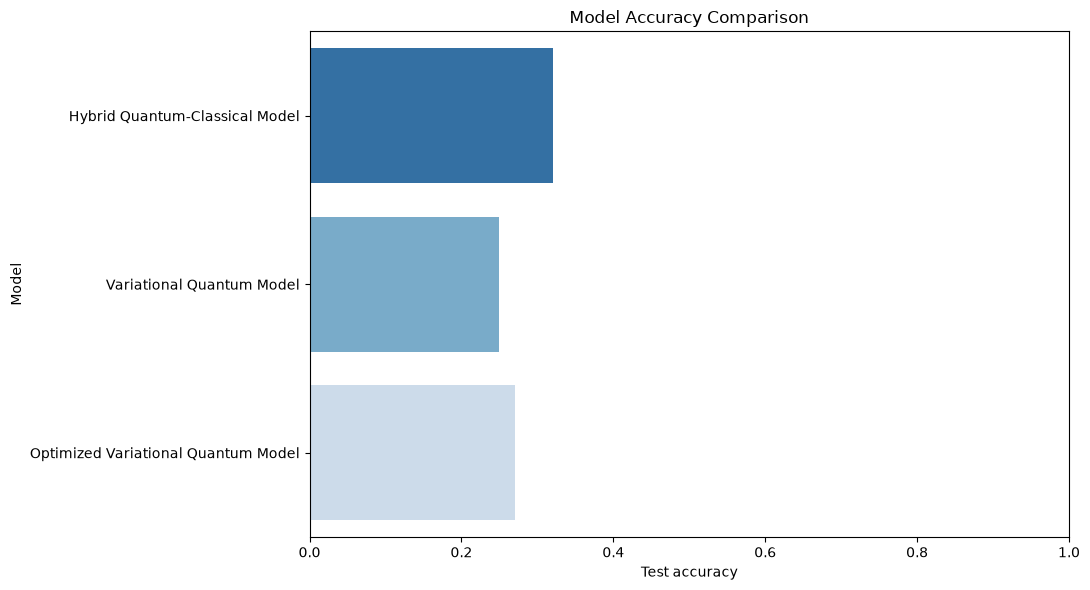

In [14]:
plt.figure(figsize=(11, 6))

accuracy_plot = (
    model_ranking
    .dropna(subset=["accuracy"])
)

sns.barplot(
    data=accuracy_plot,
    x="accuracy",
    y="model",
    hue="model",
    palette="Blues_r",
    legend=False
)

plt.xlim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Test accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

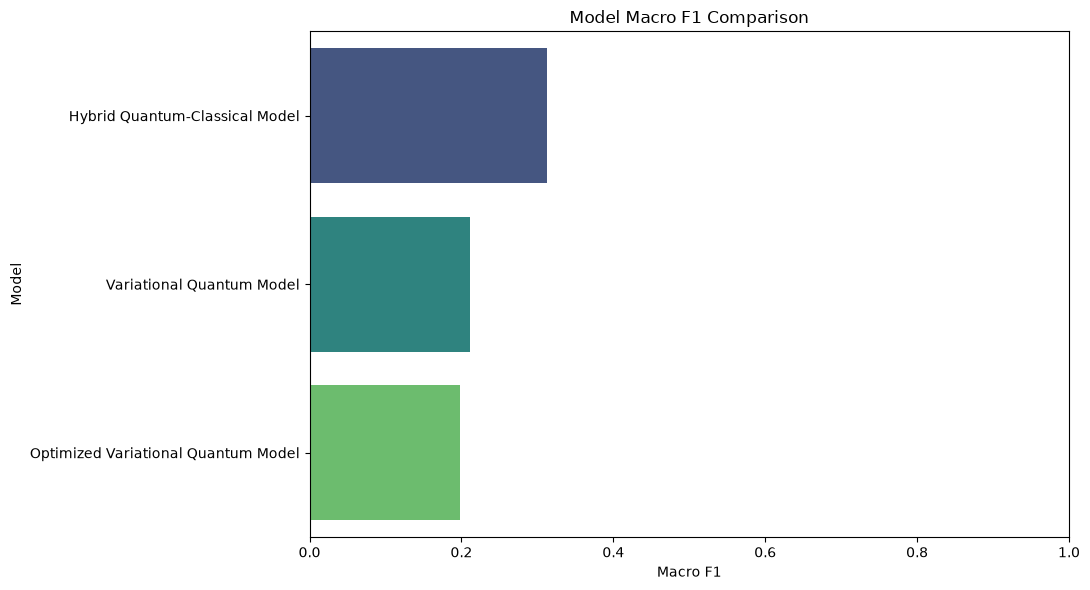

In [15]:
plt.figure(figsize=(11, 6))

f1_plot = (
    model_ranking
    .dropna(subset=["macro_f1"])
)

sns.barplot(
    data=f1_plot,
    x="macro_f1",
    y="model",
    hue="model",
    palette="viridis",
    legend=False
)

plt.xlim(0, 1)
plt.title("Model Macro F1 Comparison")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

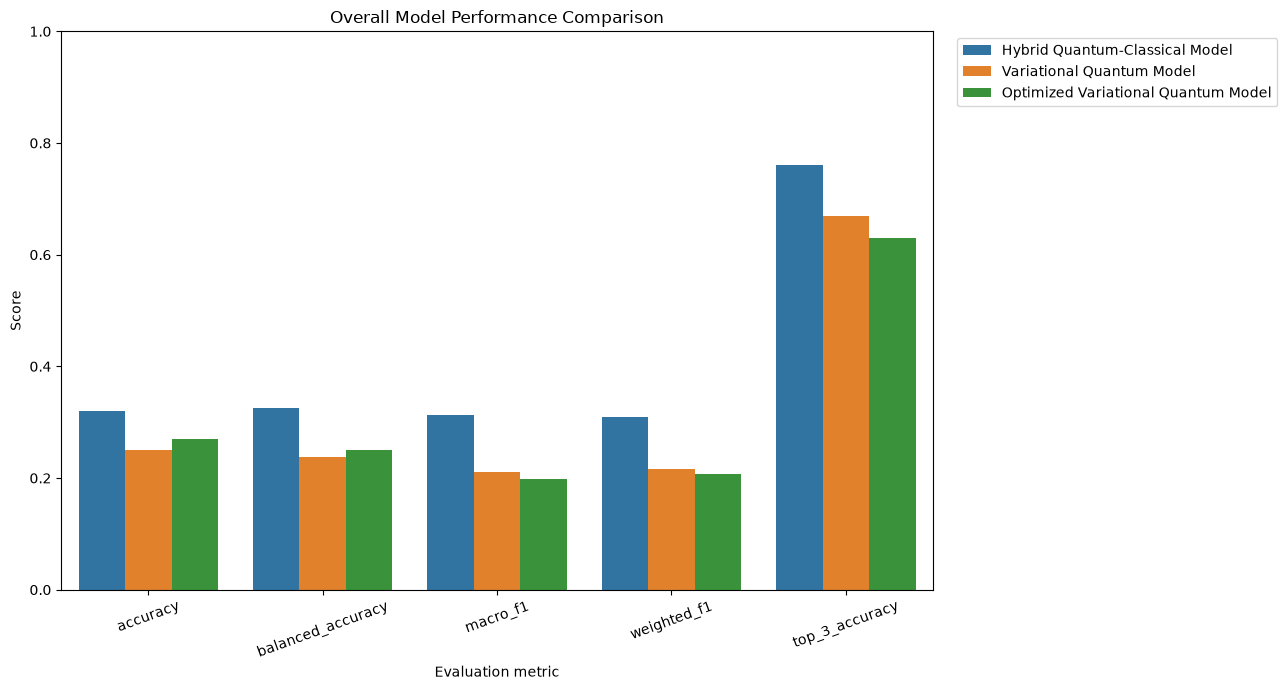

In [16]:
multi_metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "top_3_accuracy"
]

comparison_long = (
    model_ranking[
        ["model"] + multi_metric_columns
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score"
    )
    .dropna(subset=["score"])
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=comparison_long,
    x="metric",
    y="score",
    hue="model"
)

plt.ylim(0, 1)
plt.title("Overall Model Performance Comparison")
plt.xlabel("Evaluation metric")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [17]:
def load_best_model_predictions(
    model_name,
    file_name
):
    excel_file = pd.ExcelFile(file_name)

    possible_sheets = [
        "Test_Predictions",
        "Recommendations",
        "Predictions"
    ]

    for sheet_name in possible_sheets:
        if sheet_name not in excel_file.sheet_names:
            continue

        predictions = pd.read_excel(
            file_name,
            sheet_name=sheet_name
        )

        predictions = clean_columns(
            predictions
        )

        actual_candidates = [
            "actual_encoded_target",
            "actual_target",
            "actual_class",
            "y_true"
        ]

        prediction_candidates = [
            "predicted_encoded_target",
            "predicted_target",
            "predicted_class",
            "y_pred"
        ]

        actual_column = next(
            (
                column
                for column in actual_candidates
                if column in predictions.columns
            ),
            None
        )

        predicted_column = next(
            (
                column
                for column in prediction_candidates
                if column in predictions.columns
            ),
            None
        )

        if (
            actual_column is not None
            and predicted_column is not None
        ):
            return (
                predictions,
                actual_column,
                predicted_column,
                sheet_name
            )

    return None, None, None, None


best_model_file = model_ranking.loc[
    0,
    "source_file"
]

(
    best_predictions,
    actual_column,
    predicted_column,
    prediction_sheet
) = load_best_model_predictions(
    best_model_name,
    best_model_file
)

print("Best model file:", best_model_file)
print("Prediction sheet:", prediction_sheet)

Best model file: hybrid_quantum_classical_recommendation_results.xlsx
Prediction sheet: Recommendations


In [18]:
if best_predictions is not None:
    y_true_best = pd.to_numeric(
        best_predictions[actual_column],
        errors="coerce"
    ).to_numpy(dtype=np.int64)

    y_pred_best = pd.to_numeric(
        best_predictions[predicted_column],
        errors="coerce"
    ).to_numpy(dtype=np.int64)

    class_ids = np.sort(
        np.unique(y_true_best)
    )

    best_classification_report = pd.DataFrame(
        classification_report(
            y_true_best,
            y_pred_best,
            labels=class_ids,
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    best_confusion = confusion_matrix(
        y_true_best,
        y_pred_best,
        labels=class_ids
    )

    best_confusion_df = pd.DataFrame(
        best_confusion,
        index=[
            f"Actual_{class_id}"
            for class_id in class_ids
        ],
        columns=[
            f"Predicted_{class_id}"
            for class_id in class_ids
        ]
    )

    display(best_classification_report)

else:
    best_classification_report = (
        pd.DataFrame()
    )

    best_confusion_df = pd.DataFrame()

    print(
        "Detailed prediction columns were not available "
        "for the selected model."
    )

,precision,recall,f1-score,support
0,0.166667,0.125000,0.142857,8.00
1,0.285714,0.285714,0.285714,7.00
2,0.454545,0.555556,0.500000,9.00
3,0.428571,0.375000,0.400000,8.00
4,0.142857,0.100000,0.117647,10.00
5,0.200000,0.125000,0.153846,8.00
6,0.444444,0.444444,0.444444,9.00
7,0.500000,0.444444,0.470588,9.00
8,0.333333,0.428571,0.375000,7.00
9,0.166667,0.200000,0.181818,10.00


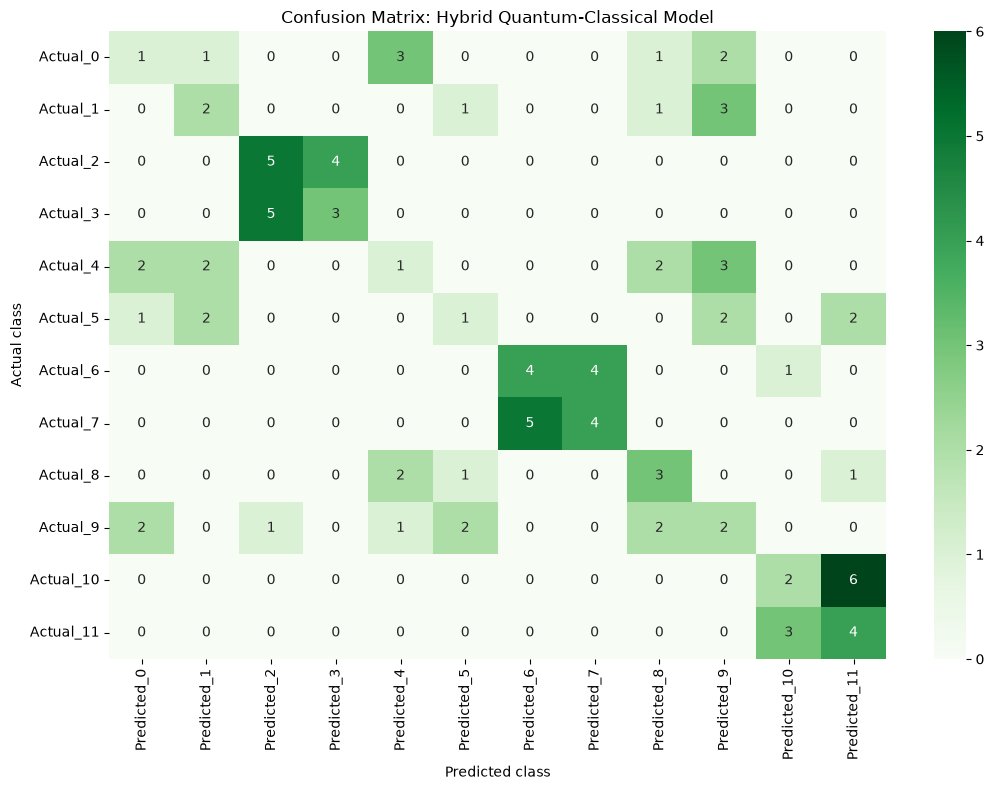

In [19]:
if not best_confusion_df.empty:
    plt.figure(figsize=(11, 8))

    sns.heatmap(
        best_confusion_df,
        annot=True,
        fmt="d",
        cmap="Greens"
    )

    plt.title(
        f"Confusion Matrix: {best_model_name}"
    )
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()

In [20]:
def bootstrap_confidence_intervals(
    targets,
    predictions,
    bootstrap_samples=1000,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    accuracy_values = []
    macro_f1_values = []

    sample_size = len(targets)

    for _ in range(bootstrap_samples):
        indices = rng.choice(
            sample_size,
            size=sample_size,
            replace=True
        )

        sampled_targets = targets[indices]
        sampled_predictions = predictions[
            indices
        ]

        accuracy_values.append(
            accuracy_score(
                sampled_targets,
                sampled_predictions
            )
        )

        _, _, sampled_macro_f1, _ = (
            precision_recall_fscore_support(
                sampled_targets,
                sampled_predictions,
                average="macro",
                zero_division=0
            )
        )

        macro_f1_values.append(
            sampled_macro_f1
        )

    return pd.DataFrame({
        "metric": [
            "accuracy",
            "macro_f1"
        ],
        "observed_value": [
            accuracy_score(
                targets,
                predictions
            ),
            precision_recall_fscore_support(
                targets,
                predictions,
                average="macro",
                zero_division=0
            )[2]
        ],
        "lower_95_percent": [
            np.quantile(
                accuracy_values,
                0.025
            ),
            np.quantile(
                macro_f1_values,
                0.025
            )
        ],
        "upper_95_percent": [
            np.quantile(
                accuracy_values,
                0.975
            ),
            np.quantile(
                macro_f1_values,
                0.975
            )
        ]
    })


if best_predictions is not None:
    best_model_intervals = (
        bootstrap_confidence_intervals(
            y_true_best,
            y_pred_best
        )
    )

    display(best_model_intervals)

else:
    best_model_intervals = pd.DataFrame()

,metric,observed_value,lower_95_percent,upper_95_percent
0,accuracy,0.320000,0.23000,0.420000
1,macro_f1,0.313136,0.22011,0.391287


In [21]:
if os.path.exists(reliability_file):
    reliability_summary = pd.read_excel(
        reliability_file,
        sheet_name="Reliability_Summary"
    )

    calibration_metrics = pd.read_excel(
        reliability_file,
        sheet_name="Calibration_Metrics"
    )

    perturbation_summary = pd.read_excel(
        reliability_file,
        sheet_name="Perturbation_Summary"
    )

    print(
        "Robustness and reliability results loaded."
    )

    display(reliability_summary)

else:
    reliability_summary = pd.DataFrame()
    calibration_metrics = pd.DataFrame()
    perturbation_summary = pd.DataFrame()

    print(
        "Reliability workbook was not found. "
        "Core model evaluation will continue."
    )

Robustness and reliability results loaded.


,measure,value
0,Baseline accuracy,0.27
1,Baseline balanced accuracy,0.250331
2,Baseline macro F1,0.197958
3,Accuracy bootstrap lower bound,0.18
4,Accuracy bootstrap upper bound,0.36
5,Macro F1 bootstrap lower bound,0.122776
6,Macro F1 bootstrap upper bound,0.261068
7,Expected calibration error,0.072035
8,Multiclass Brier score,0.78077
9,Mean confidence,0.274564


In [22]:
best_model_row = model_ranking.iloc[0]

model_selection_summary = pd.DataFrame({
    "criterion": [
        "Selected model",
        "Primary selection metric",
        "Test accuracy",
        "Balanced accuracy",
        "Macro precision",
        "Macro recall",
        "Macro F1",
        "Weighted F1",
        "Top-2 accuracy",
        "Top-3 accuracy",
        "Source file"
    ],
    "value": [
        best_model_name,
        "Macro F1",
        best_model_row["accuracy"],
        best_model_row[
            "balanced_accuracy"
        ],
        best_model_row[
            "macro_precision"
        ],
        best_model_row[
            "macro_recall"
        ],
        best_model_row["macro_f1"],
        best_model_row["weighted_f1"],
        best_model_row[
            "top_2_accuracy"
        ],
        best_model_row[
            "top_3_accuracy"
        ],
        best_model_file
    ]
})

display(model_selection_summary)

,criterion,value
0,Selected model,Hybrid Quantum-Classical Model
1,Primary selection metric,Macro F1
2,Test accuracy,0.32
3,Balanced accuracy,0.32543
4,Macro precision,0.313652
5,Macro recall,0.32543
6,Macro F1,0.313136
7,Weighted F1,0.310143
8,Top-2 accuracy,0.66
9,Top-3 accuracy,0.76


In [23]:
assert model_ranking[
    "macro_f1"
].notna().all()

assert model_ranking[
    "accuracy"
].dropna().between(0, 1).all()

assert model_ranking[
    "macro_f1"
].between(0, 1).all()

if model_ranking[
    "top_3_accuracy"
].notna().any():
    assert model_ranking[
        "top_3_accuracy"
    ].dropna().between(0, 1).all()

assert model_ranking.loc[
    0,
    "macro_f1"
] == model_ranking[
    "macro_f1"
].max()

print(
    "All model performance validation "
    "checks passed."
)

All model performance validation checks passed.


In [24]:
configuration = {
    "stage": "Model Performance Evaluation",
    "models_evaluated": (
        model_ranking["model"].tolist()
    ),
    "number_of_models": int(
        len(model_ranking)
    ),
    "primary_selection_metric":
        "macro_f1",
    "secondary_metrics": [
        "balanced_accuracy",
        "accuracy",
        "top_3_accuracy"
    ],
    "selected_model":
        str(best_model_name),
    "selected_model_macro_f1":
        float(best_model_row["macro_f1"]),
    "selected_model_accuracy":
        float(best_model_row["accuracy"]),
    "bootstrap_samples": (
        1000
        if best_predictions is not None
        else 0
    ),
    "dataset_limitation": (
        "Synthetic historical medication-class data"
    )
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    model_comparison.to_excel(
        writer,
        sheet_name="All_Model_Results",
        index=False
    )

    model_ranking.to_excel(
        writer,
        sheet_name="Final_Model_Ranking",
        index=False
    )

    model_selection_summary.to_excel(
        writer,
        sheet_name="Selected_Model",
        index=False
    )

    comparison_long.to_excel(
        writer,
        sheet_name="Metric_Long_Format",
        index=False
    )

    if not best_classification_report.empty:
        best_classification_report.to_excel(
            writer,
            sheet_name="Best_Classification_Report"
        )

    if not best_confusion_df.empty:
        best_confusion_df.to_excel(
            writer,
            sheet_name="Best_Confusion_Matrix"
        )

    if not best_model_intervals.empty:
        best_model_intervals.to_excel(
            writer,
            sheet_name="Bootstrap_Intervals",
            index=False
        )

    if not reliability_summary.empty:
        reliability_summary.to_excel(
            writer,
            sheet_name="Reliability_Summary",
            index=False
        )

    if not calibration_metrics.empty:
        calibration_metrics.to_excel(
            writer,
            sheet_name="Calibration_Metrics",
            index=False
        )

    if not perturbation_summary.empty:
        perturbation_summary.to_excel(
            writer,
            sheet_name="Perturbation_Robustness",
            index=False
        )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved evaluation:", output_file)
print("Saved configuration:", configuration_file)

Saved evaluation: final_model_performance_evaluation.xlsx
Saved configuration: model_performance_evaluation_config.json


In [25]:
for file_name in [
    output_file,
    configuration_file
]:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

saved_workbook = pd.ExcelFile(output_file)

print("\nSaved sheets:")
print(saved_workbook.sheet_names)

print("\nFinal selected model:")
print(best_model_name)

print(
    "Accuracy:",
    round(best_model_row["accuracy"], 4)
)

print(
    "Macro F1:",
    round(best_model_row["macro_f1"], 4)
)

if pd.notna(
    best_model_row["top_3_accuracy"]
):
    print(
        "Top-3 accuracy:",
        round(
            best_model_row[
                "top_3_accuracy"
            ],
            4
        )
    )

final_model_performance_evaluation.xlsx exists: True
model_performance_evaluation_config.json exists: True

Saved sheets:
['All_Model_Results', 'Final_Model_Ranking', 'Selected_Model', 'Metric_Long_Format', 'Best_Classification_Report', 'Best_Confusion_Matrix', 'Bootstrap_Intervals', 'Reliability_Summary', 'Calibration_Metrics', 'Perturbation_Robustness', 'Configuration']

Final selected model:
Hybrid Quantum-Classical Model
Accuracy: 0.32
Macro F1: 0.3131
Top-3 accuracy: 0.76
